# **Module 4:** Assignment: Using an “Off-the-shelf” Model

## Semiconductor Pass/Fail Prediction with the UCI SECOM Dataset

### Introduction
In this notebook, I revise my original Module 4 assignment by using the same UCI SECOM dataset, but with a cleaner and more professional end-to-end workflow.

I still follow the main course idea of adapting an off-the-shelf model to a new learning problem. The original inspiration came from a Kaggle notebook by Vinit, but I substantially redesigned the workflow for a tabular semiconductor sensor dataset and a pass/fail classification setting.

This version focuses on:
- a leakage-safe train / validation / test split
- clear exploratory data analysis
- missing-value handling and noisy-feature reduction
- imbalanced classification metrics that fit a pass / fail problem
- model comparison instead of relying on only one result
- a more realistic discussion of deployment

My goal is not only to get a higher score. I want a result that is easier to explain, more reproducible, and more realistic for a real manufacturing setting.

## Project framing

### Why I picked this dataset
I picked the UCI SECOM dataset because it is a real semiconductor manufacturing dataset with sensor measurements and a pass/fail label. It fits an industrial quality-monitoring scenario.

### Main questions I want to answer
1. What does the SECOM dataset look like from a data analysis perspective?
2. Which modeling approach gives the most reliable result on an imbalanced pass/fail problem?
3. Would I feel comfortable deploying the model in a real semiconductor setting?
4. What are the main limitations and next steps?

In [ ]:
import os
import copy
import random
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.10.0+cpu
CUDA available: False


## Load the data

This notebook can work in a few ways:

- If the SECOM files are already available in `data/`, it will use that repo-local folder.
- If the notebook is being run from the `notebooks/` folder, it can also use `../data/`.
- If I already uploaded `secom.data`, `secom_labels.data`, and `secom.names` to Colab, it can still use `/content/secom_project`.
- If none of those locations has the full dataset, it will download the files from the UCI Machine Learning Repository.

This keeps the notebook usable in the repo while preserving the Colab fallback.

In [ ]:
# Check common repo-local and Colab-style data locations first
required_files = ["secom.data", "secom_labels.data", "secom.names"]
candidate_dirs = [
    Path("data"),
    Path("../data"),
    Path("/content/secom_project")
]

DATA_DIR = None
for candidate_dir in candidate_dirs:
    if all((candidate_dir / file_name).exists() for file_name in required_files):
        DATA_DIR = candidate_dir
        print(f"Using existing data files from: {DATA_DIR}")
        break

if DATA_DIR is None:
    DATA_DIR = Path("/content/secom_project")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"No complete local data folder found. Using: {DATA_DIR}")

# File paths
data_file = DATA_DIR / "secom.data"
labels_file = DATA_DIR / "secom_labels.data"
names_file = DATA_DIR / "secom.names"

# UCI URLs
urls = {
    "secom.data": "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data",
    "secom_labels.data": "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data",
    "secom.names": "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.names"
}

# Download only if files are missing
for file_name, url in urls.items():
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        print(f"Downloading {file_name} ...")
        urllib.request.urlretrieve(url, str(file_path))
    else:
        print(f"Found existing file: {file_name}")

# Read feature matrix
X_raw = pd.read_csv(data_file, sep=r"\s+", header=None, engine="python")
X_raw.columns = [f"sensor_{i:03d}" for i in range(1, X_raw.shape[1] + 1)]

# Read label file
labels_df = pd.read_csv(labels_file, sep=r"\s+", header=None, engine="python")
labels_df.columns = ["label", "date_part", "time_part"]

labels_df["timestamp"] = pd.to_datetime(
    labels_df["date_part"].astype(str).str.replace('"', '', regex=False) + " " +
    labels_df["time_part"].astype(str).str.replace('"', '', regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Convert label: -1 = pass -> 0, 1 = fail -> 1
y = labels_df["label"].replace({-1: 0, 1: 1}).astype(int)

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts().sort_index())

Found existing file: secom.data
Found existing file: secom_labels.data
Found existing file: secom.names
X_raw shape: (1567, 590)
y shape: (1567,)

Target distribution:
label
0    1463
1     104
Name: count, dtype: int64


## Initial data audit

Before modeling, I want to understand:
- data size
- target imbalance
- missing-value pattern
- low-information features
- time coverage

This helps me design a more realistic pipeline.

In [ ]:
# Basic dataset summary
n_rows, n_features = X_raw.shape
class_counts = y.value_counts().sort_index()

missing_ratio = X_raw.isna().mean()
missing_count = X_raw.isna().sum()
overall_missing_pct = X_raw.isna().sum().sum() / (X_raw.shape[0] * X_raw.shape[1]) * 100

constant_features = (X_raw.nunique(dropna=True) <= 1).sum()
near_constant_features = (X_raw.nunique(dropna=True) <= 2).sum()

summary_df = pd.DataFrame({
    "metric": [
        "rows",
        "features",
        "pass_count (label 0)",
        "fail_count (label 1)",
        "fail_rate_pct",
        "overall_missing_pct",
        "features_with_any_missing",
        "features_above_30pct_missing",
        "features_above_50pct_missing",
        "constant_features",
        "near_constant_features",
        "first_timestamp",
        "last_timestamp"
    ],
    "value": [
        n_rows,
        n_features,
        int(class_counts.get(0, 0)),
        int(class_counts.get(1, 0)),
        round(100 * class_counts.get(1, 0) / len(y), 2),
        round(overall_missing_pct, 2),
        int((missing_ratio > 0).sum()),
        int((missing_ratio > 0.30).sum()),
        int((missing_ratio > 0.50).sum()),
        int(constant_features),
        int(near_constant_features),
        str(labels_df["timestamp"].min()),
        str(labels_df["timestamp"].max())
    ]
})

display(summary_df)

top_missing_df = pd.DataFrame({
    "feature": missing_ratio.sort_values(ascending=False).index[:15],
    "missing_ratio": missing_ratio.sort_values(ascending=False).values[:15],
    "missing_count": missing_count[missing_ratio.sort_values(ascending=False).index[:15]].values
})

print("Top 15 features by missing ratio:")
display(top_missing_df)

,metric,value
0,rows,1567
1,features,590
2,pass_count (label 0),1463
3,fail_count (label 1),104
4,fail_rate_pct,6.64
5,overall_missing_pct,4.54
6,features_with_any_missing,538
7,features_above_30pct_missing,32
8,features_above_50pct_missing,28
9,constant_features,116


Top 15 features by missing ratio:


,feature,missing_ratio,missing_count
0,sensor_293,0.911934,1429
1,sensor_294,0.911934,1429
2,sensor_159,0.911934,1429
3,sensor_158,0.911934,1429
4,sensor_493,0.855775,1341
5,sensor_086,0.855775,1341
6,sensor_359,0.855775,1341
7,sensor_221,0.855775,1341
8,sensor_245,0.649649,1018
9,sensor_518,0.649649,1018


## Initial interpretation

The first audit already shows why this dataset is challenging:

- The fail class is rare, so plain accuracy can be misleading.
- Missing values are spread across many sensor columns.
- Some features contain little or almost no useful variation.
- The feature space is high-dimensional compared with the number of rows.
- The timestamp-based fail-rate trend also suggests that process conditions may change over time.

Because of that, I will not rely on only one metric or one model. I will compare a few approaches and keep the test set untouched until the end.

At the same time, I treat the timestamp only as an exploratory signal in this version. A future version should also test time-based validation to see whether the model can generalize better to future production periods.

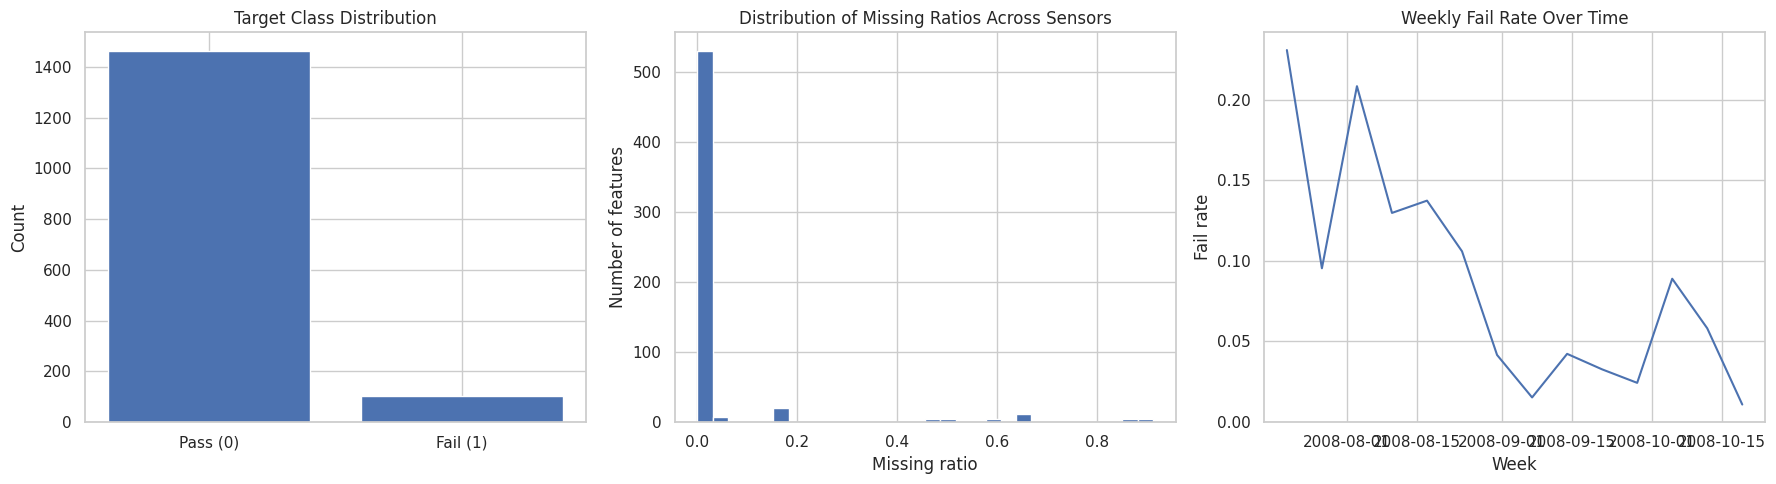

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
class_plot = y.value_counts().sort_index()
axes[0].bar(["Pass (0)", "Fail (1)"], class_plot.values)
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")

# Missing ratio histogram
axes[1].hist(missing_ratio, bins=30)
axes[1].set_title("Distribution of Missing Ratios Across Sensors")
axes[1].set_xlabel("Missing ratio")
axes[1].set_ylabel("Number of features")

# Weekly fail rate using timestamp (EDA only, not modeling)
weekly_fail = (
    pd.DataFrame({"timestamp": labels_df["timestamp"], "target": y})
    .dropna()
    .set_index("timestamp")
    .resample("W")["target"]
    .mean()
)

axes[2].plot(weekly_fail.index, weekly_fail.values)
axes[2].set_title("Weekly Fail Rate Over Time")
axes[2].set_xlabel("Week")
axes[2].set_ylabel("Fail rate")

plt.tight_layout()
plt.show()

## Note on timestamps and split strategy
The weekly fail-rate plot suggests that the process may not be perfectly stationary over time.

In this notebook, I still use a stratified random split for the main modeling workflow because:
- the fail class is very small
- I want a stable baseline comparison across models
- I want the first revised version to focus on leakage-safe preprocessing and imbalanced evaluation

However, for a more deployment-oriented manufacturing workflow, I would also want to test:
- time-based train/test splits
- rolling or backtesting-style validation
- drift checks across different production periods

So this notebook should be viewed as a strong baseline workflow, not as the final production-style validation design.

## Modeling strategy

To make this notebook more reliable than my earlier version, I will use the following rules:

1. Split the data before fitting imputation, scaling, or PCA.
2. Keep the test set completely untouched until the final evaluation.
3. Use timestamps only for EDA, not as model features.
4. Compare simple baselines before the neural network.
5. Use metrics that fit an imbalanced pass/fail problem.
6. Tune the decision threshold on the validation set instead of assuming that 0.50 is always best.
7. Treat this validation design as a baseline, while acknowledging that future work should also test time-based validation because timestamps are available.

I also keep the main workflow conservative. Instead of using SMOTE as the default path, I start with class-weighted learning and strong baselines. That makes the result easier to trust as a baseline. It does not fully replace the need for repeated or time-based validation in a real manufacturing setting.

In [ ]:
# First split: train+validation vs test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   # 0.25 of 0.80 = 0.20 overall
    stratify=y_train_full,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train shape: (939, 590)
Validation shape: (314, 590)
Test shape: (314, 590)

Train class distribution:
label
0    877
1     62
Name: count, dtype: int64

Validation class distribution:
label
0    293
1     21
Name: count, dtype: int64

Test class distribution:
label
0    293
1     21
Name: count, dtype: int64


## Note on split size and minority-class stability

The validation set and the test set each contain only 21 fail cases.

That means the estimated recall, balanced accuracy, and PR-AUC can move noticeably if only a few fail predictions change. I still use this split for a clean baseline comparison, but I treat the final numbers as approximate rather than perfectly stable estimates.

## Training-only feature filtering and preprocessing

This is one of the most important fixes in the revised notebook.

I will:
- drop sensor columns that have more than 50% missing values based only on the training set
- impute remaining missing values using the training-set median
- remove constant features
- standardize the linear / neural-network version
- use PCA only for the linear / neural-network version

One important detail is that the earlier missing-value audit used the full dataset only for descriptive understanding.

The actual feature filtering rule in the modeling pipeline is fit on the training split only, so the final dropped-column count may differ from the full-data audit. That difference is expected and helps avoid leakage.

Next, for the Random Forest model, I will keep a simpler preprocessing path without PCA.

In [ ]:
def select_feature_columns_by_missingness(X_train_df, missing_threshold=0.50):
    train_missing_ratio = X_train_df.isna().mean()
    keep_cols = train_missing_ratio[train_missing_ratio <= missing_threshold].index.tolist()
    drop_cols = train_missing_ratio[train_missing_ratio > missing_threshold].index.tolist()
    return keep_cols, drop_cols, train_missing_ratio

def fit_linear_preprocessor(X_train_df, pca_variance=0.95):
    imputer = SimpleImputer(strategy="median")
    variance_selector = VarianceThreshold(threshold=0.0)
    scaler = StandardScaler()
    pca = PCA(n_components=pca_variance, random_state=42)

    X_imp = imputer.fit_transform(X_train_df)
    X_var = variance_selector.fit_transform(X_imp)
    X_scaled = scaler.fit_transform(X_var)
    X_pca = pca.fit_transform(X_scaled)

    bundle = {
        "imputer": imputer,
        "variance_selector": variance_selector,
        "scaler": scaler,
        "pca": pca
    }
    return bundle, X_pca

def transform_linear_preprocessor(X_df, bundle):
    X_imp = bundle["imputer"].transform(X_df)
    X_var = bundle["variance_selector"].transform(X_imp)
    X_scaled = bundle["scaler"].transform(X_var)
    X_pca = bundle["pca"].transform(X_scaled)
    return X_pca

def fit_tree_preprocessor(X_train_df):
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_train_df)
    bundle = {"imputer": imputer}
    return bundle, X_imp

def transform_tree_preprocessor(X_df, bundle):
    return bundle["imputer"].transform(X_df)

# Select columns using training data only
keep_cols, drop_cols, train_missing_ratio = select_feature_columns_by_missingness(X_train, missing_threshold=0.50)

# Keep the same columns across all splits
X_train_keep = X_train[keep_cols].copy()
X_val_keep = X_val[keep_cols].copy()
X_test_keep = X_test[keep_cols].copy()

# Linear / MLP preprocessing
linear_bundle, X_train_linear = fit_linear_preprocessor(X_train_keep, pca_variance=0.95)
X_val_linear = transform_linear_preprocessor(X_val_keep, linear_bundle)
X_test_linear = transform_linear_preprocessor(X_test_keep, linear_bundle)

# Tree preprocessing
tree_bundle, X_train_tree = fit_tree_preprocessor(X_train_keep)
X_val_tree = transform_tree_preprocessor(X_val_keep, tree_bundle)
X_test_tree = transform_tree_preprocessor(X_test_keep, tree_bundle)

print(f"Original feature count: {X_raw.shape[1]}")
print(f"Kept after missingness filter: {len(keep_cols)}")
print(f"Dropped because missing ratio > 50% in training set: {len(drop_cols)}")
print(f"Linear / MLP feature count after PCA: {X_train_linear.shape[1]}")
print(f"Tree model feature count after imputation only: {X_train_tree.shape[1]}")

full_data_drop_count = int((missing_ratio > 0.50).sum())
train_only_drop_count = len(drop_cols)

print(f"Full-data descriptive count above 50% missing: {full_data_drop_count}")
print(f"Training-only modeling count above 50% missing: {train_only_drop_count}")
print("Difference is expected because the final filter is fit on the training split only to avoid leakage.")

Original feature count: 590
Kept after missingness filter: 566
Dropped because missing ratio > 50% in training set: 24
Linear / MLP feature count after PCA: 157
Tree model feature count after imputation only: 566
Full-data descriptive count above 50% missing: 28
Training-only modeling count above 50% missing: 24
Difference is expected because the final filter is fit on the training split only to avoid leakage.


## Evaluation helpers

For this pass/fail problem, I will focus on:
- balanced accuracy
- precision
- recall
- F1
- ROC-AUC
- PR-AUC

I will also tune the classification threshold on the validation set to maximize balanced accuracy. This threshold should be treated as an operating decision rule, not as a universal default. A lower threshold may improve fail recall, but it can also increase false positives. In a real manufacturing setting, the final threshold should be chosen together with process or quality stakeholders based on operational cost.

In [ ]:
def calculate_metrics(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "threshold": round(float(threshold), 3),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_true, y_pred), 4),
        "specificity": round(specificity, 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc": round(average_precision_score(y_true, y_prob), 4)
    }

def find_best_threshold(y_true, y_prob, metric="balanced_accuracy"):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_threshold = 0.50
    best_score = -np.inf

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        if metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)
        elif metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError("Supported metrics: balanced_accuracy, f1, recall")

        if score > best_score:
            best_score = score
            best_threshold = threshold

    return best_threshold, best_score

def plot_confusion(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pass (0)", "Fail (1)"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

## Classical baselines

I will compare three models first:

1. Dummy Classifier  
   This is a sanity check baseline.

2. Logistic Regression + PCA  
   This is a simple, transparent baseline for a high-dimensional numeric dataset.

3. Random Forest  
   This gives me a stronger nonlinear baseline and some feature importance later if needed.

In [ ]:
validation_rows = []

# 1) Dummy classifier
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_tree, y_train)

dummy_val_prob = dummy_model.predict_proba(X_val_tree)[:, 1]
dummy_threshold = 0.50
dummy_metrics = calculate_metrics(y_val, dummy_val_prob, threshold=dummy_threshold)
validation_rows.append({"model": "Dummy Classifier", **dummy_metrics})

# 2) Logistic Regression + PCA
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    solver="liblinear",
    random_state=42
)
log_model.fit(X_train_linear, y_train)

log_val_prob = log_model.predict_proba(X_val_linear)[:, 1]
log_threshold, log_best_score = find_best_threshold(y_val, log_val_prob, metric="balanced_accuracy")
log_metrics = calculate_metrics(y_val, log_val_prob, threshold=log_threshold)
validation_rows.append({"model": "Logistic Regression + PCA", **log_metrics})

# 3) Random Forest
rf_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_tree, y_train)

rf_val_prob = rf_model.predict_proba(X_val_tree)[:, 1]
rf_threshold, rf_best_score = find_best_threshold(y_val, rf_val_prob, metric="balanced_accuracy")
rf_metrics = calculate_metrics(y_val, rf_val_prob, threshold=rf_threshold)
validation_rows.append({"model": "Random Forest", **rf_metrics})

validation_results = pd.DataFrame(validation_rows).sort_values(
    by=["balanced_accuracy", "pr_auc", "recall"],
    ascending=False
).reset_index(drop=True)

display(validation_results)

,model,threshold,accuracy,balanced_accuracy,specificity,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.110,0.7102,0.6458,0.7201,0.1277,0.5714,0.2087,0.6608,0.1329
1,Logistic Regression + PCA,0.305,0.8280,0.6205,0.8601,0.1633,0.3810,0.2286,0.6433,0.1509
2,Dummy Classifier,0.500,0.9331,0.5000,1.0000,0.0000,0.0000,0.0000,0.5000,0.0669


## Validation result interpretation

On this validation split, Random Forest gives the strongest balanced accuracy, while Logistic Regression + PCA remains competitive on some other metrics such as F1 and PR-AUC.

Because the validation set contains only 21 fail cases, I do not interpret these model gaps as final proof that one model is universally best. Instead, I treat Random Forest as the strongest candidate on this split and then verify it on the untouched test set.

## Neural-network version

To stay aligned with the AI course, I also build a revised MLP for tabular sensor data.

Key design choices:
- use the leakage-safe preprocessed training data
- use class-weighted loss instead of applying oversampling by default
- use dropout and batch normalization
- use early stopping based on validation balanced accuracy

For simplicity, the early-stopping rule monitors validation balanced accuracy at the default 0.50 threshold during training.

After training, I still search for a better operating threshold on the validation set for final comparison. A more rigorous future version could align these two steps more tightly by using a threshold-free metric such as ROC-AUC or PR-AUC for early stopping, or by jointly selecting epoch and threshold.

This keeps the neural-network part more realistic and easier to defend.

In [ ]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

def predict_mlp_proba(model, X_array, device):
    model.eval()
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    return probs

def train_mlp(
    X_train_array,
    y_train_array,
    X_val_array,
    y_val_array,
    lr=1e-3,
    max_epochs=100,
    batch_size=64,
    patience=15
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TabularMLP(input_dim=X_train_array.shape[1]).to(device)

    class_counts = np.bincount(y_train_array)
    class_weights = len(y_train_array) / (2.0 * class_counts)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    train_dataset = TensorDataset(
        torch.tensor(X_train_array, dtype=torch.float32),
        torch.tensor(y_train_array, dtype=torch.long)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_score = -np.inf
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)

        avg_train_loss = running_loss / len(train_dataset)

        val_prob = predict_mlp_proba(model, X_val_array, device)
        val_pred = (val_prob >= 0.50).astype(int)
        val_bal_acc = balanced_accuracy_score(y_val_array, val_pred)
        val_recall = recall_score(y_val_array, val_pred, zero_division=0)

        history.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_balanced_accuracy": val_bal_acc,
            "val_recall": val_recall
        })

        if val_bal_acc > best_val_score:
            best_val_score = val_bal_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}. Best epoch: {best_epoch}")
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)

    return model, history_df, device

Early stopping triggered at epoch 22. Best epoch: 7


,epoch,train_loss,val_balanced_accuracy,val_recall
17,18,0.032906,0.562815,0.190476
18,19,0.021307,0.544125,0.142857
19,20,0.018224,0.540712,0.142857
20,21,0.017465,0.498212,0.047619
21,22,0.012916,0.547538,0.142857


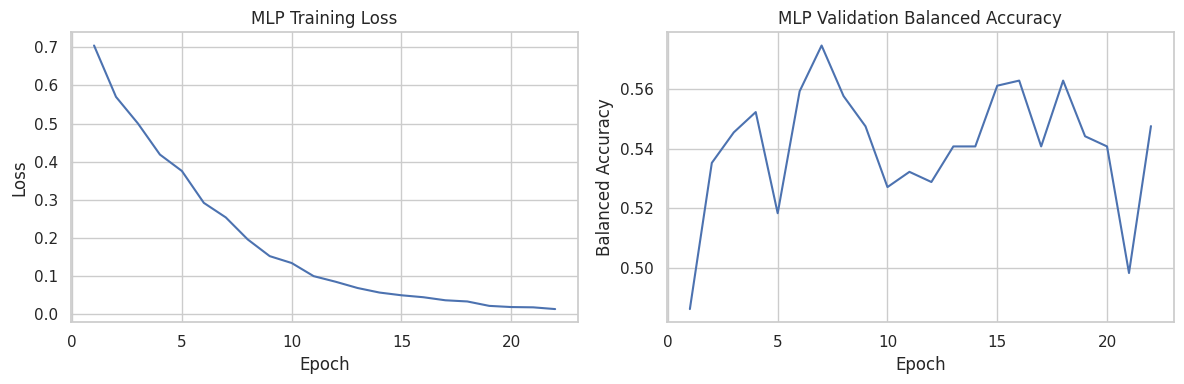

,model,threshold,accuracy,balanced_accuracy,specificity,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.110,0.7102,0.6458,0.7201,0.1277,0.5714,0.2087,0.6608,0.1329
1,Weighted MLP,0.125,0.3535,0.6315,0.3106,0.0901,0.9524,0.1646,0.6285,0.1253
2,Logistic Regression + PCA,0.305,0.8280,0.6205,0.8601,0.1633,0.3810,0.2286,0.6433,0.1509
3,Dummy Classifier,0.500,0.9331,0.5000,1.0000,0.0000,0.0000,0.0000,0.5000,0.0669


In [ ]:
# Convert targets to numpy arrays for PyTorch
y_train_np = y_train.to_numpy().astype(int)
y_val_np = y_val.to_numpy().astype(int)

# Train MLP
mlp_model, mlp_history, mlp_device = train_mlp(
    X_train_array=X_train_linear.astype(np.float32),
    y_train_array=y_train_np,
    X_val_array=X_val_linear.astype(np.float32),
    y_val_array=y_val_np,
    lr=1e-3,
    max_epochs=100,
    batch_size=64,
    patience=15
)

display(mlp_history.tail())

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mlp_history["epoch"], mlp_history["train_loss"])
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(mlp_history["epoch"], mlp_history["val_balanced_accuracy"])
plt.title("MLP Validation Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")

plt.tight_layout()
plt.show()

# Validation metrics for MLP
mlp_val_prob = predict_mlp_proba(mlp_model, X_val_linear.astype(np.float32), mlp_device)
mlp_threshold, mlp_best_score = find_best_threshold(y_val_np, mlp_val_prob, metric="balanced_accuracy")
mlp_metrics = calculate_metrics(y_val_np, mlp_val_prob, threshold=mlp_threshold)

mlp_row = pd.DataFrame([{"model": "Weighted MLP", **mlp_metrics}])

validation_results = pd.concat([validation_results, mlp_row], ignore_index=True)
validation_results = validation_results.sort_values(
    by=["balanced_accuracy", "pr_auc", "recall"],
    ascending=False
).reset_index(drop=True)

display(validation_results)

## MLP result interpretation

The weighted MLP pushes recall very high on the validation set, but it does so at the cost of very low precision and much lower overall accuracy.

That pattern is not surprising for a small, imbalanced tabular dataset. In this case, the neural network acts more like an aggressive fail detector than a balanced production candidate. This is one reason I do not assume that a deep-learning model is automatically the best choice for the SECOM data.

## Model selection

At this point, I compare all validation results and pick one final model for the untouched test set.

I use validation balanced accuracy as the main decision rule because:
- the dataset is imbalanced
- both pass and fail detection matter
- plain accuracy can look good even when fail detection is weak

I still treat this as a split-specific selection decision, not as a final ranking that would necessarily hold across all resamples or future time periods.

I also keep PR-AUC and fail recall in mind because the fail class is rare.

In [ ]:
# Suggested model based on validation results
suggested_final_model = validation_results.iloc[0]["model"]
print("Best model on this validation split:", suggested_final_model)

# You can manually override this after reviewing the table if needed.
FINAL_MODEL_NAME = suggested_final_model
print("Final model selected for test evaluation:", FINAL_MODEL_NAME)

model_registry = {
    "Dummy Classifier": {
        "model": dummy_model,
        "threshold": dummy_threshold,
        "X_test": X_test_tree,
        "kind": "sklearn"
    },
    "Logistic Regression + PCA": {
        "model": log_model,
        "threshold": log_threshold,
        "X_test": X_test_linear,
        "kind": "sklearn"
    },
    "Random Forest": {
        "model": rf_model,
        "threshold": rf_threshold,
        "X_test": X_test_tree,
        "kind": "sklearn"
    },
    "Weighted MLP": {
        "model": mlp_model,
        "threshold": mlp_threshold,
        "X_test": X_test_linear.astype(np.float32),
        "kind": "mlp",
        "device": mlp_device
    }
}

Best model on this validation split: Random Forest
Final model selected for test evaluation: Random Forest


## Final evaluation on the untouched test set

This is the first time I look at the test set.

That is important because I want the test result to reflect a more honest estimate of real-world performance.

At the same time, I still interpret this test result carefully:
- the test set contains only 21 fail cases
- the final classification threshold was selected on the validation set
- the chosen threshold reflects a recall-vs-false-positive trade-off, not a universal production setting

So I use the test set as an honest holdout evaluation, while still treating the final operating point as a prototype decision rule.

,model,threshold,accuracy,balanced_accuracy,specificity,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.11,0.7898,0.6663,0.8089,0.1642,0.5238,0.25,0.7978,0.2192


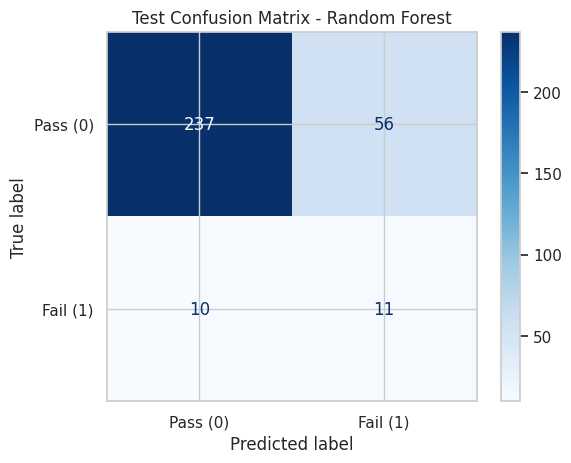

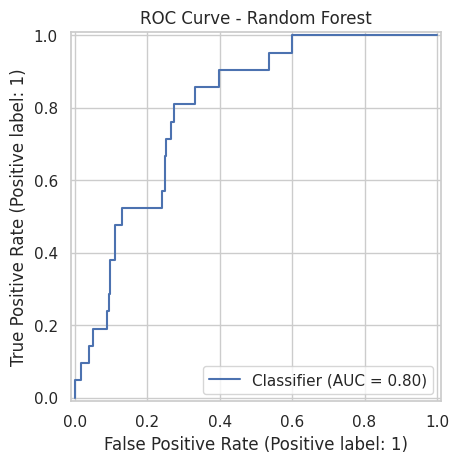

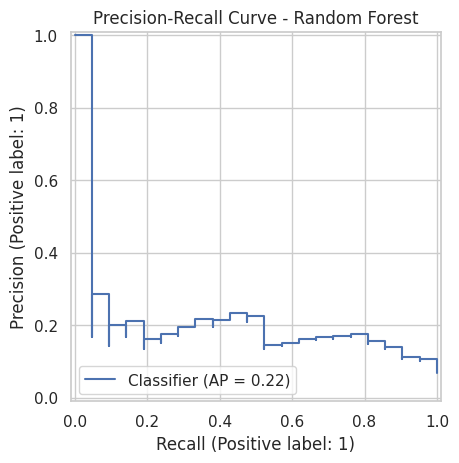

In [ ]:
selected = model_registry[FINAL_MODEL_NAME]

if selected["kind"] == "sklearn":
    test_prob = selected["model"].predict_proba(selected["X_test"])[:, 1]
else:
    test_prob = predict_mlp_proba(selected["model"], selected["X_test"], selected["device"])

test_metrics = calculate_metrics(y_test, test_prob, threshold=selected["threshold"])
test_results_df = pd.DataFrame([{"model": FINAL_MODEL_NAME, **test_metrics}])

display(test_results_df)

plot_confusion(
    y_true=y_test,
    y_prob=test_prob,
    threshold=selected["threshold"],
    title=f"Test Confusion Matrix - {FINAL_MODEL_NAME}"
)

RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"ROC Curve - {FINAL_MODEL_NAME}")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title(f"Precision-Recall Curve - {FINAL_MODEL_NAME}")
plt.show()

## Test-set operating interpretation

Using the selected threshold, the Random Forest model catches 11 of the 21 fail cases on the test set, which gives a fail recall of about 52%.

However, it also produces many false positives. This means the model may be useful as an early screening tool, but not yet as a fully automated accept/reject decision system.

In a real semiconductor workflow, I would want to set the threshold together with quality or process engineers based on:
- the cost of missing a bad unit
- the cost of unnecessary reinspection
- the acceptable false alarm volume for downstream operations

## Optional interpretation

If the final model is Random Forest, I can inspect the most important sensor features directly. These importances are useful for model interpretation and candidate signal review, but they do not prove that a sensor is a true physical root cause of failure.

If the final model is Logistic Regression + PCA, the coefficients are on principal components, so interpretation is less direct.

If the final model is the MLP, this notebook focuses more on predictive workflow than model explainability.

,importance
sensor_060,0.017984
sensor_104,0.015005
sensor_181,0.008863
sensor_478,0.007840
sensor_034,0.007401
sensor_206,0.007347
sensor_342,0.007073
sensor_126,0.007007
sensor_130,0.006728
sensor_065,0.006266


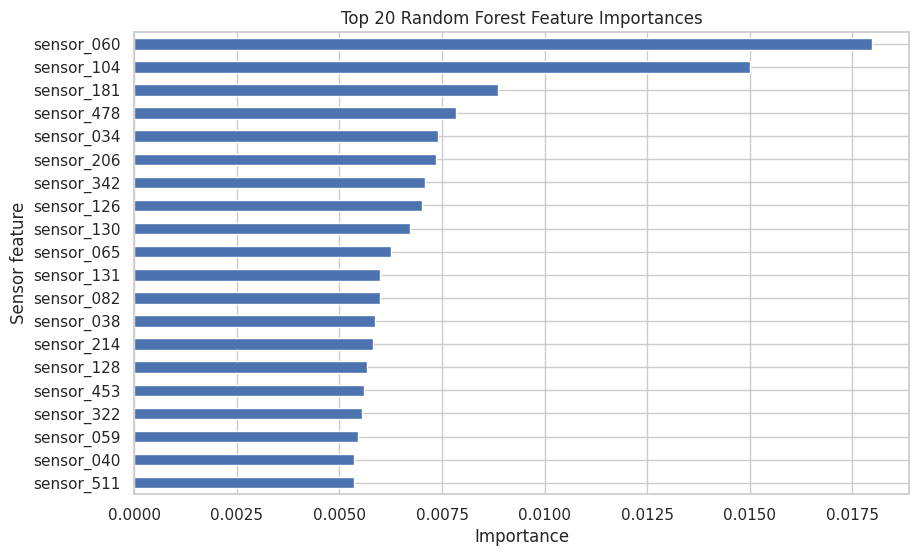

In [ ]:
if FINAL_MODEL_NAME == "Random Forest":
    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=keep_cols
    ).sort_values(ascending=False).head(20)

    display(feature_importance.to_frame("importance"))

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind="barh")
    plt.title("Top 20 Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Sensor feature")
    plt.show()

elif FINAL_MODEL_NAME == "Logistic Regression + PCA":
    pc_names = [f"PC_{i+1:03d}" for i in range(X_train_linear.shape[1])]
    coef_importance = pd.Series(
        np.abs(log_model.coef_[0]),
        index=pc_names
    ).sort_values(ascending=False).head(20)

    display(coef_importance.to_frame("absolute_coefficient"))

    plt.figure(figsize=(10, 6))
    coef_importance.sort_values().plot(kind="barh")
    plt.title("Top 20 Logistic Regression Coefficients (Absolute Value)")
    plt.xlabel("Absolute coefficient")
    plt.ylabel("Principal component")
    plt.show()

else:
    print("For the final MLP model, I am not showing feature importance in this notebook.")
    print("A future version could add SHAP, permutation importance, or other explainability methods.")

## Caution on feature importance

The feature-importance chart helps identify which sensor variables were most influential for this Random Forest model on this split.

I treat these as model-driven screening signals, not as direct evidence of process causality. A real manufacturing interpretation would require:
- sensor-domain knowledge
- process-step context
- engineering validation
- stability checks across multiple retraining runs or validation periods

## Final conclusion

This revised notebook gives me a more trustworthy version of the SECOM project.

### What changed from the original off-the-shelf tutorial
- I adapted the problem from a tutorial-style AI workflow to a semiconductor tabular classification problem.
- I used sensor measurements instead of image inputs.
- I added missing-value handling, feature filtering, and leakage-safe preprocessing.
- I compared multiple models instead of relying on only one neural-network result.
- I used balanced metrics and threshold tuning for an imbalanced pass/fail problem.

### Main difficulty
The main difficulties were:
- severe class imbalance
- many missing values
- many noisy or low-information sensor variables
- a small number of fail cases compared with pass cases

### Deployment view
Even if the final model performs well, I would still not deploy it immediately in a real semiconductor manufacturing setting.

Before deployment, I would still want:
- cross-validation across multiple splits
- stronger monitoring for drift and false negatives
- cost-based threshold selection with process engineers
- clearer understanding of which sensor signals are stable and operationally available at scoring time
- a retraining and model-monitoring plan
- validation under time-based splits, because timestamps suggest the process may shift over time
- more stable minority-class estimation, because the number of fail cases is small

So, my final view is that this notebook is a stronger analytical prototype and a more realistic course project, but still not a production-ready manufacturing model.

## Summary

**Semiconductor Pass/Fail Prediction using Sensor Data (UCI SECOM)**  
- Adapted an off-the-shelf AI workflow to a semiconductor manufacturing tabular dataset  
- Performed data audit, missing-value analysis, class-imbalance analysis, and time-based exploratory review  
- Built a leakage-safe train/validation/test pipeline with feature filtering, median imputation, scaling, and PCA  
- Compared Dummy Classifier, Logistic Regression, Random Forest, and a class-weighted PyTorch MLP  
- Evaluated models using balanced accuracy, recall, PR-AUC, ROC-AUC, confusion matrix, and threshold tuning  
- Framed results in terms of manufacturing quality monitoring, deployment risk, and model-governance considerations
- Chose the final model on validation balanced accuracy while treating the result as split-specific because the fail class is small
- Interpreted the selected threshold and feature importance carefully from an operational and non-causal perspective

## Short reflection

This revised version is better than my earlier notebook because it is more careful about leakage, model comparison, threshold selection, and imbalanced evaluation.

It also shows a more realistic analyst mindset: I am not only trying to maximize a score, but also trying to explain the modeling limits, deployment risks, and next validation steps.

**Reference:**


1. UCI Machine Learning Repository. [SECOM Dataset.](https://archive.ics.uci.edu/dataset/179/secom)
2. Vinit. (2024). [Semiconductor/IOT-MachineLearning. Kaggle.](https://www.kaggle.com/code/vinitkp/semiconductor-iot-machinelearning)
3. Howard, J., & Gugger, S. (2020). [Deep Learning for Coders with Fastai and PyTorch. O'Reilly.](https://learning.oreilly.com/library/view/deep-learning-for/9781492045519/ch06.html#idm46055304729416)
4. Tam, A. (2023). [Building Multilayer Perceptron Models in PyTorch.](https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/)